In [2]:
"""
AE 498 Planetary Defense - HW3
Gooding Angles-Only IOD for 2024PDC25

Full solver version with corrections.
"""

import xml.etree.ElementTree as ET
import numpy as np
from datetime import datetime, timezone
import urllib.request
from skyfield.api import load
from lambert import lambert, stumpff_S, stumpff_C

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

AU        = 1.495978707e11           # m/AU
MU_SUN_SI = 1.32712440018e20         # m^3/s^2
DAY       = 86400.0
MU        = MU_SUN_SI * DAY**2 / AU**3   # AU^3/day^2

# ─────────────────────────────────────────────────────────────────────────────
# LOAD SKYFIELD EPHEMERIS
# ─────────────────────────────────────────────────────────────────────────────

ts    = load.timescale()
eph   = load("de440s.bsp")
earth = eph["earth"]
sun   = eph["sun"]

print("Skyfield ephemeris loaded.\n")

# ─────────────────────────────────────────────────────────────────────────────
# 1. FETCH / LOAD XML
# ─────────────────────────────────────────────────────────────────────────────

URL = "https://cneos.jpl.nasa.gov/pd/cs/pdc25/2024pdc25.xml"

print(f"Fetching astrometry data from:\n  {URL}\n")
with urllib.request.urlopen(URL) as response:
    xml_data = response.read()

root = ET.fromstring(xml_data)

# ─────────────────────────────────────────────────────────────────────────────
# 2. PARSE ASTROMETRY
# ─────────────────────────────────────────────────────────────────────────────

observations = []

for obs in root.findall("optical"):
    record = {
        "trkSub":  obs.findtext("trkSub"),
        "mode":    obs.findtext("mode"),
        "stn":     obs.findtext("stn"),
        "obsTime": obs.findtext("obsTime"),
        "ra_deg":  float(obs.findtext("ra")),
        "dec_deg": float(obs.findtext("dec")),
        "rmsRA":   float(obs.findtext("rmsRA")),
        "rmsDec":  float(obs.findtext("rmsDec")),
        "mag":     float(obs.findtext("mag")),
        "band":    obs.findtext("band"),
    }

    dt = datetime.strptime(record["obsTime"], "%Y-%m-%dT%H:%M:%S.%fZ")
    dt = dt.replace(tzinfo=timezone.utc)

    unix_ts = dt.timestamp()
    jd = 2440587.5 + unix_ts / 86400.0

    record["JD"] = jd
    record["datetime"] = dt
    record["ra_rad"] = np.deg2rad(record["ra_deg"])
    record["dec_rad"] = np.deg2rad(record["dec_deg"])

    observations.append(record)

observations.sort(key=lambda x: x["JD"])

# ─────────────────────────────────────────────────────────────────────────────
# 3. PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print(f"{'='*60}")
print(f"  2024PDC25 Astrometry Data Summary")
print(f"{'='*60}")
print(f"  Total observations  : {len(observations)}")
print(f"  Station code        : {observations[0]['stn']} (geocentric)")
print(f"  Obs mode            : {observations[0]['mode']}")
print(f"  First observation   : {observations[0]['obsTime']}")
print(f"  Last  observation   : {observations[-1]['obsTime']}")
print(f"  Arc length          : {observations[-1]['JD'] - observations[0]['JD']:.1f} days")
print(f"  RA  range           : {min(o['ra_deg'] for o in observations):.4f} → "
      f"{max(o['ra_deg'] for o in observations):.4f} deg")
print(f"  Dec range           : {min(o['dec_deg'] for o in observations):.4f} → "
      f"{max(o['dec_deg'] for o in observations):.4f} deg")
print(f"  rmsRA               : {observations[0]['rmsRA']} arcsec (uniform)")
print(f"  rmsDec              : {observations[0]['rmsDec']} arcsec (uniform)")
print(f"{'='*60}\n")

header = f"{'#':>4}  {'Date (UTC)':^24}  {'JD':^15}  {'RA (deg)':^12}  {'Dec (deg)':^12}"
print(header)
print("-" * len(header))

to_show = observations[:5] + [None] + observations[-5:]
for obs in to_show:
    if obs is None:
        print("  ...")
        continue
    idx = observations.index(obs) + 1
    print(f"{idx:>4}  {obs['obsTime']:^24}  {obs['JD']:15.6f}  "
          f"{obs['ra_deg']:12.6f}  {obs['dec_deg']:12.6f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. BUILD NUMPY ARRAYS
# ─────────────────────────────────────────────────────────────────────────────

t_jd      = np.array([o["JD"] for o in observations])
ra_deg    = np.array([o["ra_deg"] for o in observations])
dec_deg   = np.array([o["dec_deg"] for o in observations])
ra_rad    = np.array([o["ra_rad"] for o in observations])
dec_rad   = np.array([o["dec_rad"] for o in observations])
sigma_ra  = np.array([o["rmsRA"] for o in observations])
sigma_dec = np.array([o["rmsDec"] for o in observations])

print(f"\nNumpy arrays ready:")
print(f"  t_jd      shape: {t_jd.shape}")
print(f"  ra_deg    shape: {ra_deg.shape}")
print(f"  dec_deg   shape: {dec_deg.shape}")
print(f"  sigma_ra  shape: {sigma_ra.shape}")
print(f"  sigma_dec shape: {sigma_dec.shape}")
print("\nData loading complete. Ready for Initial Orbit Determination.")

# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def los_vector(ra_rad, dec_rad):
    """Unit line-of-sight vector from RA/Dec [rad], J2000 equatorial."""
    return np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad)
    ])

def earth_pos(dt):
    """
    Earth heliocentric position [AU, J2000] using Skyfield + de440s.
    Uses UTC datetime correctly.
    """
    t = ts.from_datetime(dt)
    return (earth - sun).at(t).position.au

# ─────────────────────────────────────────────────────────────────────────────
# KEPLER PROPAGATOR (UNIVERSAL VARIABLE χ)
# ─────────────────────────────────────────────────────────────────────────────

def kepler_prop(r0, v0, dt, mu=MU, tol=1e-8, max_iter=1000):
    """Propagate (r0, v0) by dt [days]. Returns (r_new, v_new)."""
    r0n   = np.linalg.norm(r0)
    v0n   = np.linalg.norm(v0)
    vr0   = np.dot(r0, v0) / r0n
    alpha = 2 / r0n - v0n**2 / mu

    # Better initial guess
    if abs(alpha) > 1e-12:
        chi = np.sqrt(mu) * abs(alpha) * dt
    else:
        chi = np.sqrt(mu) * dt / r0n

    n = 0
    ratio = 1.0
    while abs(ratio) > tol and n <= max_iter:
        n += 1
        z = alpha * chi**2
        C = stumpff_C(z)
        S = stumpff_S(z)

        F = (
            r0n * vr0 / np.sqrt(mu) * chi**2 * C
            + (1 - alpha * r0n) * chi**3 * S
            + r0n * chi
            - np.sqrt(mu) * dt
        )

        dFdx = (
            r0n * vr0 / np.sqrt(mu) * chi * (1 - z * S)
            + (1 - alpha * r0n) * chi**2 * C
            + r0n
        )

        ratio = F / dFdx
        chi = chi - ratio

    z  = alpha * chi**2
    C  = stumpff_C(z)
    S  = stumpff_S(z)
    f  = 1 - chi**2 * C / r0n
    g  = dt - chi**3 * S / np.sqrt(mu)
    r  = f * r0 + g * v0
    rn = np.linalg.norm(r)

    fd = (np.sqrt(mu) / (rn * r0n)) * (z * S - 1) * chi
    gd = 1 - chi**2 * C / rn
    v  = fd * r0 + gd * v0

    return r, v

# ─────────────────────────────────────────────────────────────────────────────
# STATE VECTOR → KEPLERIAN ELEMENTS
# ─────────────────────────────────────────────────────────────────────────────

def get_perihelion_distance(a, e):
    """Calculate perihelion distance."""
    if e < 1.0:
        return a * (1 - e)
    return abs(a) * (e - 1)

def rv_to_elements(r_vec, v_vec, mu=MU):
    """Returns dict of classical orbital elements. r [AU], v [AU/day]."""
    r     = np.linalg.norm(r_vec)
    v     = np.linalg.norm(v_vec)
    h_vec = np.cross(r_vec, v_vec)
    h     = np.linalg.norm(h_vec)

    a = 1 / (2 / r - v**2 / mu)

    e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r
    e     = np.linalg.norm(e_vec)

    i = np.degrees(np.arctan2(np.sqrt(h_vec[0]**2 + h_vec[1]**2), h_vec[2]))

    N_vec = np.cross(np.array([0.0, 0.0, 1.0]), h_vec)
    N     = np.linalg.norm(N_vec)

    if N == 0:
        Omega = 0.0
    else:
        Omega = np.degrees(np.arctan2(N_vec[1], N_vec[0])) % 360

    omega = 0.0
    nu    = 0.0

    if N != 0 and e != 0:
        omega = np.degrees(
            np.arctan2(
                np.dot(h_vec, np.cross(N_vec, e_vec)) / h,
                np.dot(N_vec, e_vec)
            )
        ) % 360

    if e != 0:
        nu = np.degrees(
            np.arctan2(
                np.dot(h_vec, np.cross(e_vec, r_vec)) / h,
                np.dot(e_vec, r_vec)
            )
        ) % 360

    T = 2 * np.pi * np.sqrt(a**3 / mu) if e < 1 else None
    q = get_perihelion_distance(a, e)

    return dict(a=a, e=e, i=i, Omega=Omega, omega=omega, nu=nu, T_days=T, q=q)

def equatorial_to_ecliptic(r_eq, v_eq):
    """Rotate state vectors from J2000 equatorial to J2000 ecliptic."""
    eps = np.radians(23.43928)
    Rx = np.array([
        [1, 0, 0],
        [0,  np.cos(eps), np.sin(eps)],
        [0, -np.sin(eps), np.cos(eps)]
    ])
    return Rx @ r_eq, Rx @ v_eq

# ─────────────────────────────────────────────────────────────────────────────
# GOODING IOD HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def compute_ef_eg(s, A2):
    """
    Compute orthonormal basis (e_f, e_g) spanning the plane orthogonal to A2.
    """
    s_norm = np.linalg.norm(s)
    if s_norm > 0:
        e_f = s / s_norm
    else:
        tmp = np.array([1.0, 0.0, 0.0]) if abs(A2[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        e_f = tmp - np.dot(tmp, A2) * A2
        e_f /= np.linalg.norm(e_f)
    e_g = np.cross(A2, e_f)
    return e_f, e_g

def gooding_residual(x, y, R1, R2, R3, A1, A2, A3, t1, t2, t3,
                     e_f=None, e_g=None, mu=MU):
    """
    Compute cross-track residual scalars (f, g) for range pair (x=rho1, y=rho3).
    """
    r1 = R1 + x * A1
    r3 = R3 + y * A3

    v1, _ = lambert(r1, r3, t3 - t1, string='pro', mu=mu)
    r_c, _ = kepler_prop(r1, v1, t2 - t1, mu=mu)

    rho_c = np.dot(A2, r_c - R2)
    s = r_c - (R2 + rho_c * A2)

    if e_f is None or e_g is None:
        e_f, e_g = compute_ef_eg(s, A2)

    return np.dot(e_f, s), np.dot(e_g, s), s, r1, v1, e_f, e_g

# ─────────────────────────────────────────────────────────────────────────────
# FULL GOODING NEWTON SOLVER
# ─────────────────────────────────────────────────────────────────────────────

def gooding_iod(R1, R2, R3, A1, A2, A3, t1, t2, t3,
                mu=MU, x0=0.3, y0=0.5, max_iter=100, tol=1e-6):
    """
    Gooding IOD Newton-Raphson.
    Returns:
        r2_final_eq  : state position at t2 in J2000 equatorial [AU]
        v2_final_eq  : state velocity at t2 in J2000 equatorial [AU/day]
        elements     : classical elements from J2000 ecliptic state
        converged    : bool
    """
    x, y = float(x0), float(y0)

    print(f"\n{'─'*54}")
    print(f"  Gooding IOD — Newton-Raphson")
    print(f"{'─'*54}")
    print(f"  {'Iter':>4}  {'rho1 (AU)':>11}  {'rho3 (AU)':>11}  {'|s| (AU)':>11}")
    print(f"  {'----':>4}  {'---------':>11}  {'---------':>11}  {'---------':>11}")

    converged = False

    for it in range(max_iter):
        try:
            f, g, s, r1, v1, e_f, e_g = gooding_residual(
                x, y, R1, R2, R3, A1, A2, A3, t1, t2, t3, mu=mu
            )

            r1_mag = np.linalg.norm(r1)
            r3_mag = np.linalg.norm(R3 + y * A3)
            hx = 0.001 * r1_mag
            hy = 0.001 * r3_mag

            fx, gx, *_ = gooding_residual(
                x + hx, y, R1, R2, R3, A1, A2, A3, t1, t2, t3,
                e_f=e_f, e_g=e_g, mu=mu
            )
            fy, gy, *_ = gooding_residual(
                x, y + hy, R1, R2, R3, A1, A2, A3, t1, t2, t3,
                e_f=e_f, e_g=e_g, mu=mu
            )

        except RuntimeError as err:
            print(f"  Lambert failed at iter {it}: {err}")
            break

        f_x = (fx - f) / hx
        f_y = (fy - f) / hy
        g_x = (gx - g) / hx
        g_y = (gy - g) / hy

        D = f_x * g_y - f_y * g_x

        s_norm = np.linalg.norm(s)
        print(f"  {it:>4}  {x:>11.6f}  {y:>11.6f}  {s_norm:>11.3e}")

        if s_norm < tol:
            converged = True
            break

        if abs(D) < 1e-20:
            print("  WARNING: Jacobian singular (D≈0), stopping.")
            break

        dx = -(f * g_y - g * f_y) / D
        dy =  (f * g_x - g * f_x) / D

        alpha = 1.0
        for _ in range(64):
            xn = x + alpha * dx
            yn = y + alpha * dy

            if xn > 1e-6 and yn > 1e-6:
                try:
                    _, _, sn, *_ = gooding_residual(
                        xn, yn, R1, R2, R3, A1, A2, A3, t1, t2, t3, mu=mu
                    )
                    if np.linalg.norm(sn) < s_norm:
                        break
                except Exception:
                    pass

            alpha *= 0.5

        x += alpha * dx
        y += alpha * dy

    print(f"{'─'*54}")
    status = "CONVERGED" if converged else "not fully converged"
    print(f"  {status}  rho1={x:.5f} AU   rho3={y:.5f} AU")

    # Final recovered states
    r1_final = R1 + x * A1
    r3_final = R3 + y * A3
    v1_final, _ = lambert(r1_final, r3_final, t3 - t1, string='pro', mu=mu)

    r2_prop, v2_final = kepler_prop(r1_final, v1_final, t2 - t1, mu=mu)

    rho_c = np.dot(A2, r2_prop - R2)
    r2_final = R2 + rho_c * A2

    # Elements in ecliptic frame
    r2_ecl, v2_ecl = equatorial_to_ecliptic(r2_final, v2_final)
    elems = rv_to_elements(r2_ecl, v2_ecl, mu=mu)

    return r2_final, v2_final, elems, converged

# ─────────────────────────────────────────────────────────────────────────────
# SELECT OBSERVATIONS
# ─────────────────────────────────────────────────────────────────────────────

OBS_INDICES = (20, 50, 98)

i1, i2, i3 = [i - 1 for i in OBS_INDICES]
o1, o2, o3 = observations[i1], observations[i2], observations[i3]

print(f"{'='*54}")
print(f"  2024PDC25 — Gooding Angles-Only IOD")
print(f"{'='*54}")
print(f"  Obs 1 (#{OBS_INDICES[0]:>3}): {o1['obsTime']}")
print(f"  Obs 2 (#{OBS_INDICES[1]:>3}): {o2['obsTime']}")
print(f"  Obs 3 (#{OBS_INDICES[2]:>3}): {o3['obsTime']}")
print(f"  Arc span: {o3['JD'] - o1['JD']:.1f} days")

t1, t2, t3 = o1["JD"], o2["JD"], o3["JD"]

A1 = los_vector(o1["ra_rad"], o1["dec_rad"])
A2 = los_vector(o2["ra_rad"], o2["dec_rad"])
A3 = los_vector(o3["ra_rad"], o3["dec_rad"])

R1 = earth_pos(o1["datetime"])
R2 = earth_pos(o2["datetime"])
R3 = earth_pos(o3["datetime"])

r2, v2, elems, converged = gooding_iod(
    R1, R2, R3, A1, A2, A3, t1, t2, t3,
    mu=MU, x0=0.3, y0=0.5, max_iter=100, tol=1e-6
)

print(f"\n{'='*54}")
print(f"  IOD Orbital Elements  (epoch: {o2['obsTime']})")
print(f"{'='*54}")
print(f"  a     = {elems['a']:.6f}  AU")
print(f"  e     = {elems['e']:.6f}")
print(f"  i     = {elems['i']:.4f}  deg")
print(f"  Omega = {elems['Omega']:.4f}  deg")
print(f"  omega = {elems['omega']:.4f}  deg")
print(f"  nu    = {elems['nu']:.4f}  deg")
if elems['T_days'] is not None:
    print(f"  T     = {elems['T_days']:.2f} days  ({elems['T_days'] / 365.25:.3f} yr)")
print(f"\n  r2 = {r2}  AU   [J2000 equatorial]")
print(f"  v2 = {v2}  AU/day   [J2000 equatorial]")
print(f"{'='*54}")

if converged:
    print("\nIOD converged successfully.")
else:
    print("\nIOD did not fully converge.")

Skyfield ephemeris loaded.

Fetching astrometry data from:
  https://cneos.jpl.nasa.gov/pd/cs/pdc25/2024pdc25.xml

  2024PDC25 Astrometry Data Summary
  Total observations  : 98
  Station code        : 500 (geocentric)
  Obs mode            : CCD
  First observation   : 2024-06-05T00:00:00.00Z
  Last  observation   : 2024-07-31T02:24:00.00Z
  Arc length          : 56.1 days
  RA  range           : 175.6082 → 252.3594 deg
  Dec range           : 8.0568 → 27.8266 deg
  rmsRA               : 0.2 arcsec (uniform)
  rmsDec              : 0.2 arcsec (uniform)

   #         Date (UTC)               JD           RA (deg)     Dec (deg)  
---------------------------------------------------------------------------
   1  2024-06-05T00:00:00.00Z    2460466.500000    175.608196     27.426642
   2  2024-06-05T02:24:00.00Z    2460466.600000    175.807604     27.442472
   3  2024-06-06T00:00:00.00Z    2460467.500000    177.606354     27.570900
   4  2024-06-06T02:24:00.00Z    2460467.600000    177.8066

In [3]:
import numpy as np


def obstime_to_mjd(obstime_str):
    """
    Convert obsTime string (ISO 8601) to MJD.
    e.g. '2024-07-31T00:00:00.00Z' -> 60522.0
    """
    from datetime import datetime, timezone

    # Strip trailing Z and parse
    s = obstime_str.rstrip('Z')
    dt = datetime.fromisoformat(s).replace(tzinfo=timezone.utc)

    # JD of Unix epoch (1970-01-01 00:00:00 UTC)
    JD_UNIX = 2440587.5
    MJD_OFFSET = 2400000.5

    unix_sec = dt.timestamp()
    jd = JD_UNIX + unix_sec / 86400.0
    mjd = jd - MJD_OFFSET

    return mjd



def time_of_periapse(a, e, nu_deg, t_mjd, mu=1.32712440018e20):
    """
    Compute time of periapse passage T0 in MJD.
    
    Parameters
    ----------
    a     : float  semi-major axis [meters]
    e     : float  eccentricity
    nu_deg: float  true anomaly [degrees]
    t_mjd : float  epoch time [MJD]
    mu    : float  gravitational parameter [m^3/s^2], default = Sun
    
    Returns
    -------
    T0_mjd : float  time of periapse passage [MJD]
    """
    nu = np.radians(nu_deg)

    if e < 1:  # Elliptical
        # True anomaly -> Eccentric anomaly
        E = 2 * np.arctan2(
            np.sqrt(1 - e) * np.sin(nu / 2),
            np.sqrt(1 + e) * np.cos(nu / 2)
        )
        # Mean anomaly (Kepler's equation)
        M = E - e * np.sin(E)
        # Mean motion [rad/s]
        n = np.sqrt(mu / a**3)
        # Time since periapse [seconds]
        dt_sec = M / n

    elif e > 1:  # Hyperbolic
        # True anomaly -> Hyperbolic anomaly
        H = 2 * np.arctanh(
            np.sqrt((e - 1) / (e + 1)) * np.tan(nu / 2)
        )
        # Hyperbolic Kepler's equation
        M_H = e * np.sinh(H) - H
        # Mean motion [rad/s]
        n = np.sqrt(mu / a**3)
        dt_sec = M_H / n

    else:  # Parabolic (e ≈ 1), need q
        raise ValueError("Parabolic orbit: use time_of_periapse_parabolic(q, nu, t_mjd) instead.")

    # Convert dt from seconds to days
    dt_days = dt_sec / 86400.0

    T0_mjd = t_mjd - dt_days
    return T0_mjd


def time_of_periapse_parabolic(q, nu_deg, t_mjd, mu=1.32712440018e20):
    """
    Compute T0 for a parabolic orbit (e = 1) using Barker's equation.
    
    Parameters
    ----------
    q     : float  periapse distance [meters]
    nu_deg: float  true anomaly [degrees]
    t_mjd : float  epoch time [MJD]
    mu    : float  gravitational parameter [m^3/s^2]
    """
    nu = np.radians(nu_deg)
    D = np.tan(nu / 2)
    dt_sec = np.sqrt(2 * q**3 / mu) * (D + D**3 / 3)
    dt_days = dt_sec / 86400.0
    return t_mjd - dt_days


# ── Example usage ────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Earth around Sun (approx)
    AU = 1.495978707e11   # meters per AU
    a   = elems['a'] * AU        # 1 AU
    e   = elems['e']
    nu  = elems['nu']
    t   = obstime_to_mjd(o2['obsTime'])        # MJD (2024-06-05)
    mu_sun = 1.32712440018e20  # m^3/s^2

    T0 = time_of_periapse(a, e, nu, t, mu=mu_sun)
    print(f"Time of periapse passage: MJD {T0:.6f}")

    # Convert MJD back to approx calendar hint
    from datetime import datetime, timedelta
    mjd_epoch = datetime(1858, 11, 17)
    T0_date = mjd_epoch + timedelta(days=T0)
    print(f"Approx calendar date:     {T0_date.strftime('%Y-%m-%d')}")

Time of periapse passage: MJD 60440.213899
Approx calendar date:     2024-05-10


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
Read in 98 observations from the file.
	Filtered to 98 observations that satisfy the time range and accepted observatory constraints.
Applying Eggl et al. (2020) debiasing scheme to the observations.
	Unknown star catalog: UNK
	No debiasing needed for 0 observations.
	Debiased 0 observations.
	No bias information for 98 observations.
Applying Vereš et al. (2017) weighting scheme to the observations.
	Using 0 CCD observations with station-specific weight rules.
Applying sqrt(N/4) deweighting scheme.
	Deweighted 98 observations.
Iteration

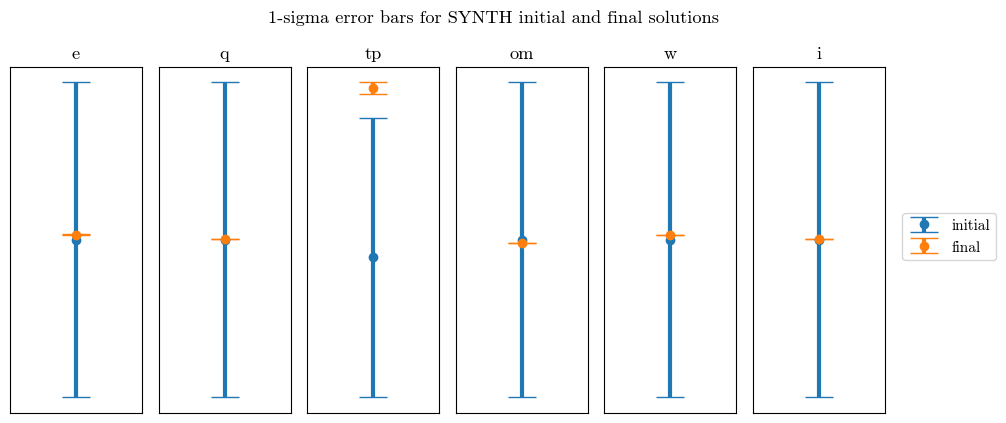

Summary of the orbit fit calculations after postfit pass:
RMS unweighted: 0.0036223968511310918
RMS weighted: 0.000731809541188343
chi-squared: 0.00010496686009656143
reduced chi-squared: 5.524571584029549e-07
square root of reduced chi-squared: 0.0007432746184304661
--------------------------------------------------------------
Solution Time: MJD 60490.100 TDB = 2024-06-29 02:24:00.000 TDB
Solution Observation Arc: 56.10 days (0.15 years)
--------------------------------------------------------------
Fitted Variable		Initial Value			Uncertainty			Fitted Value			Uncertainty			Change				Change (sigma)
e			3.80196571413e-01		3.16227766017e-01		3.90656424305e-01		3.99773949337e-04		+1.04598528925e-02		+26.164
q			1.00423010003e+00		3.16227766017e-01		1.00537193902e+00		3.71810153901e-05		+1.14183898987e-03		+30.710
tp			6.04402138994e+04		3.16227766017e-01		6.04405970409e+04		1.26767830269e-02		+3.83141502607e-01		+30.224
om			2.14762834119e+02		1.81185163576e+01		2.14426013156e+02		1.172

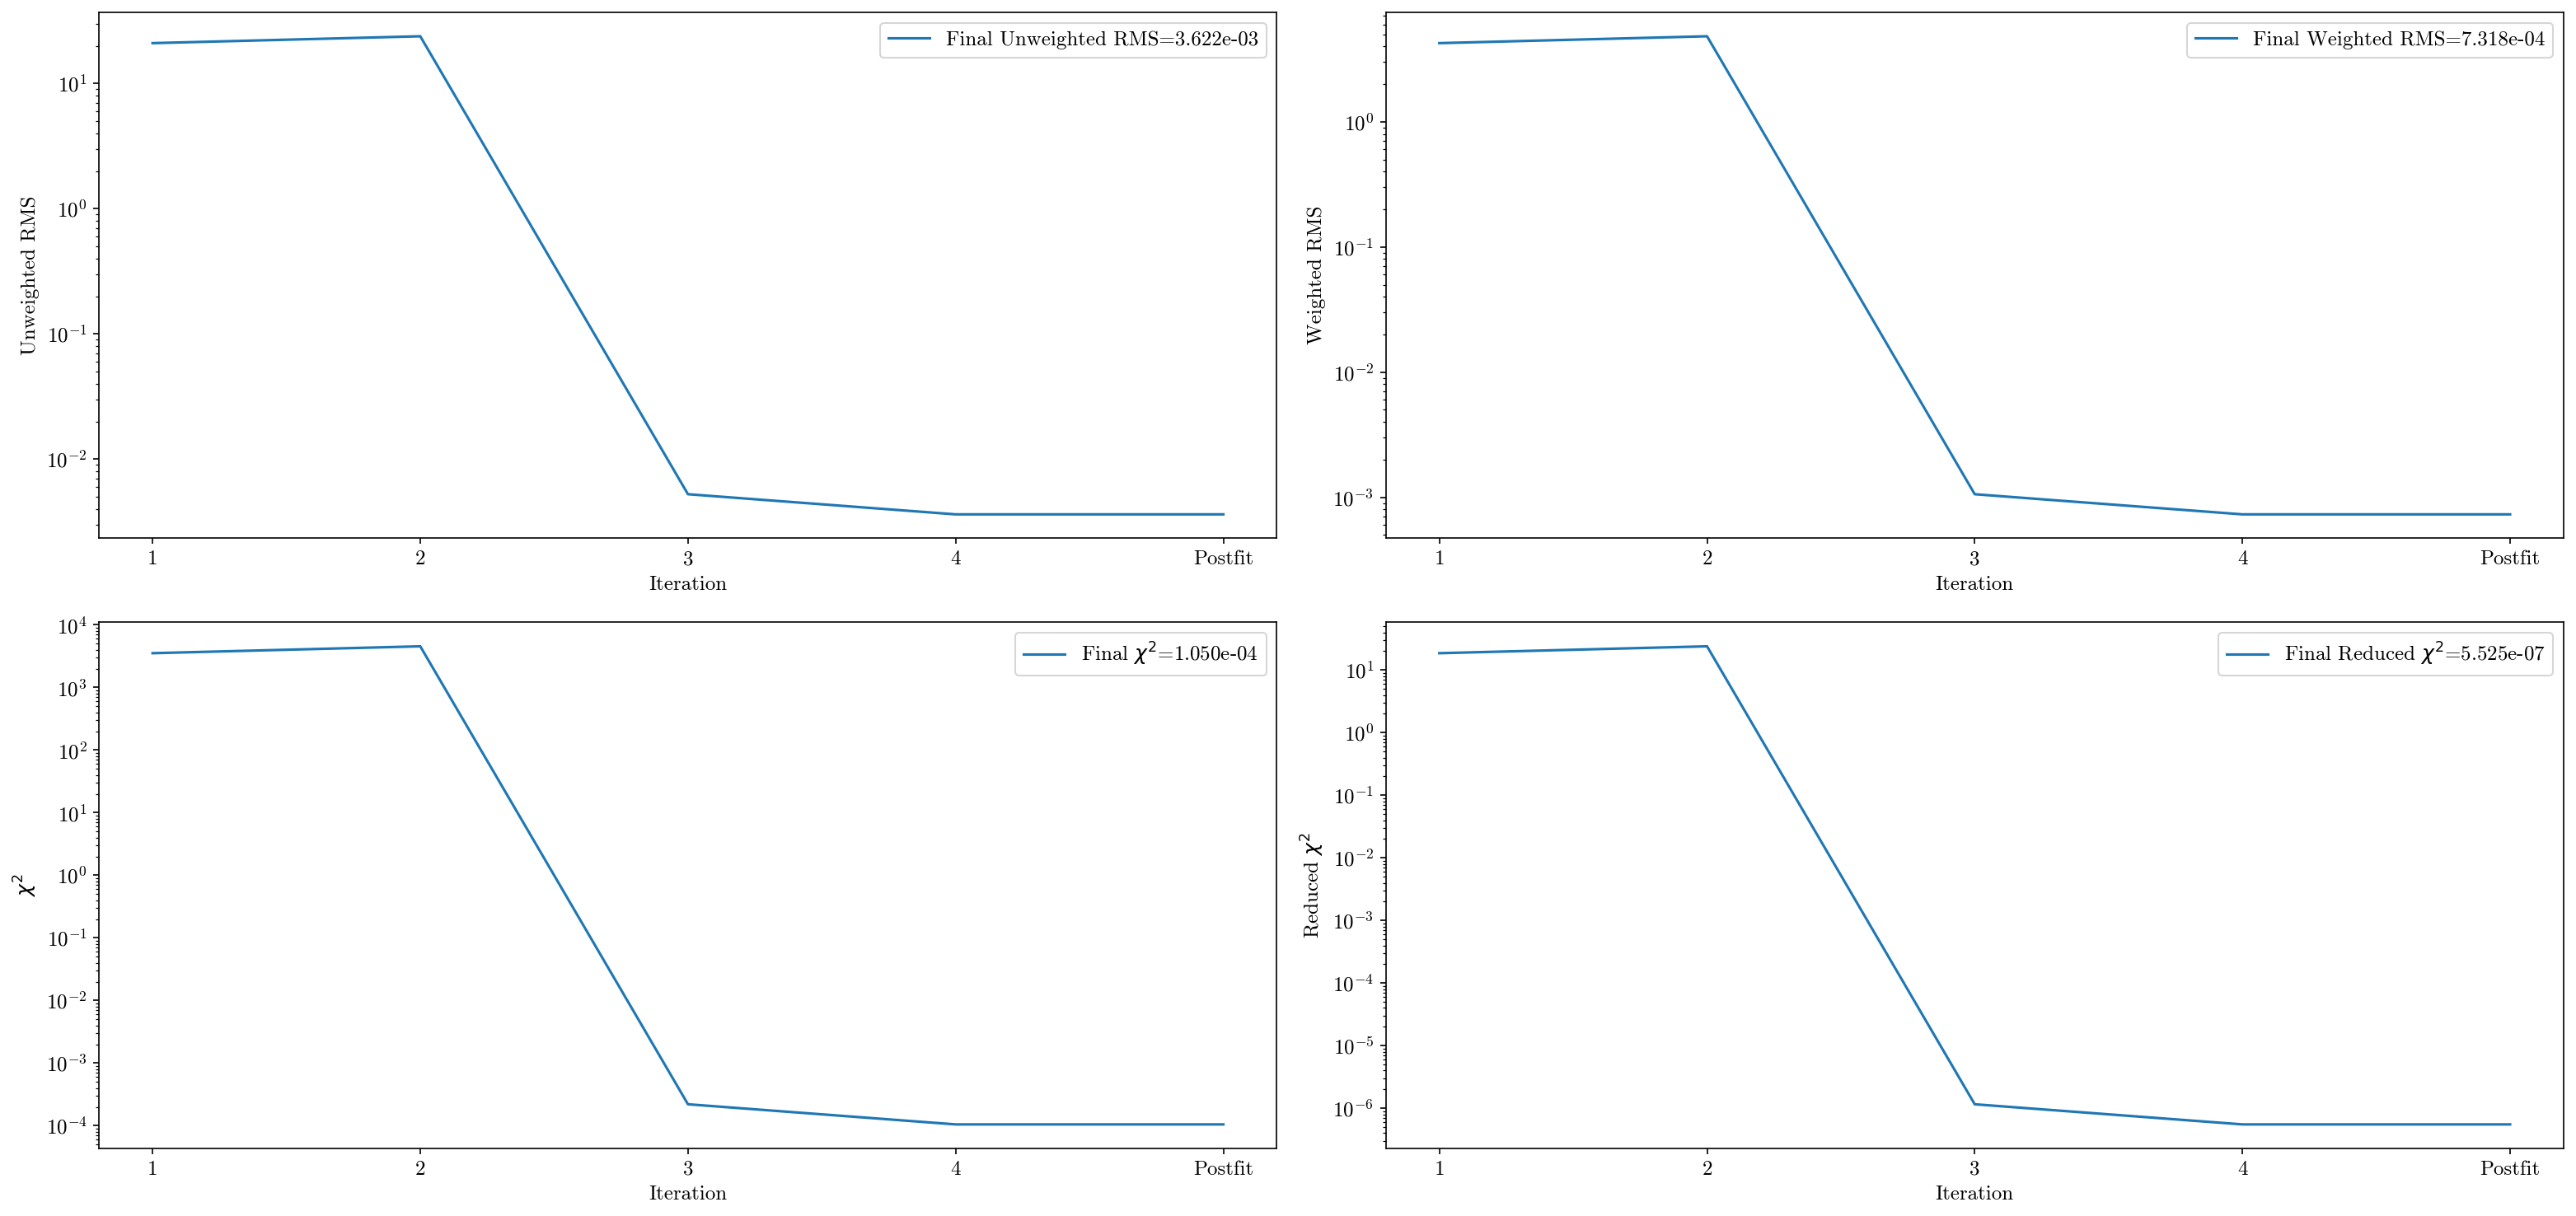

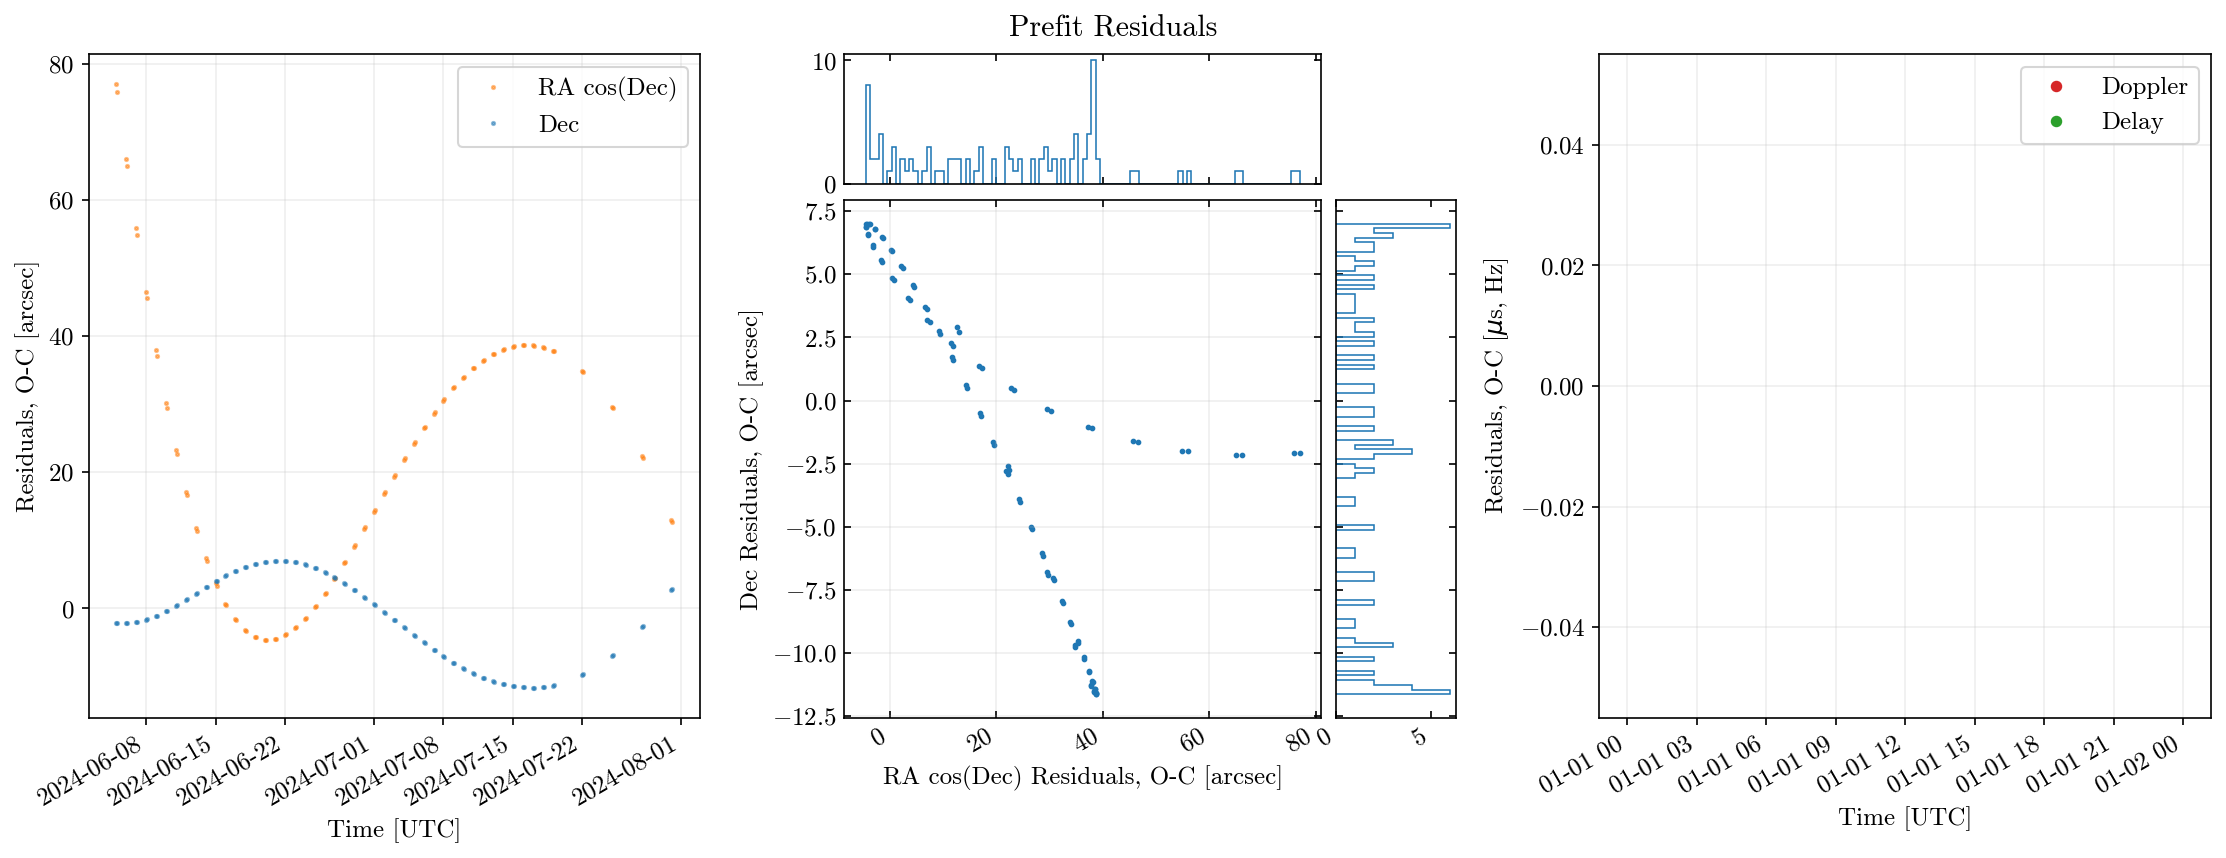

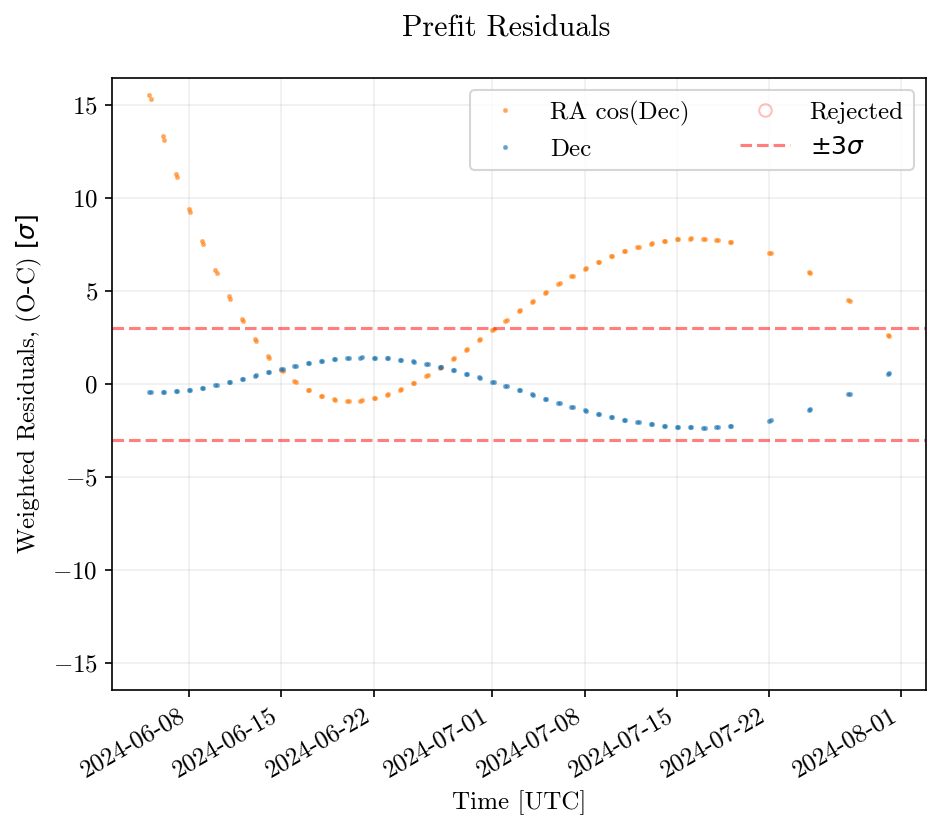

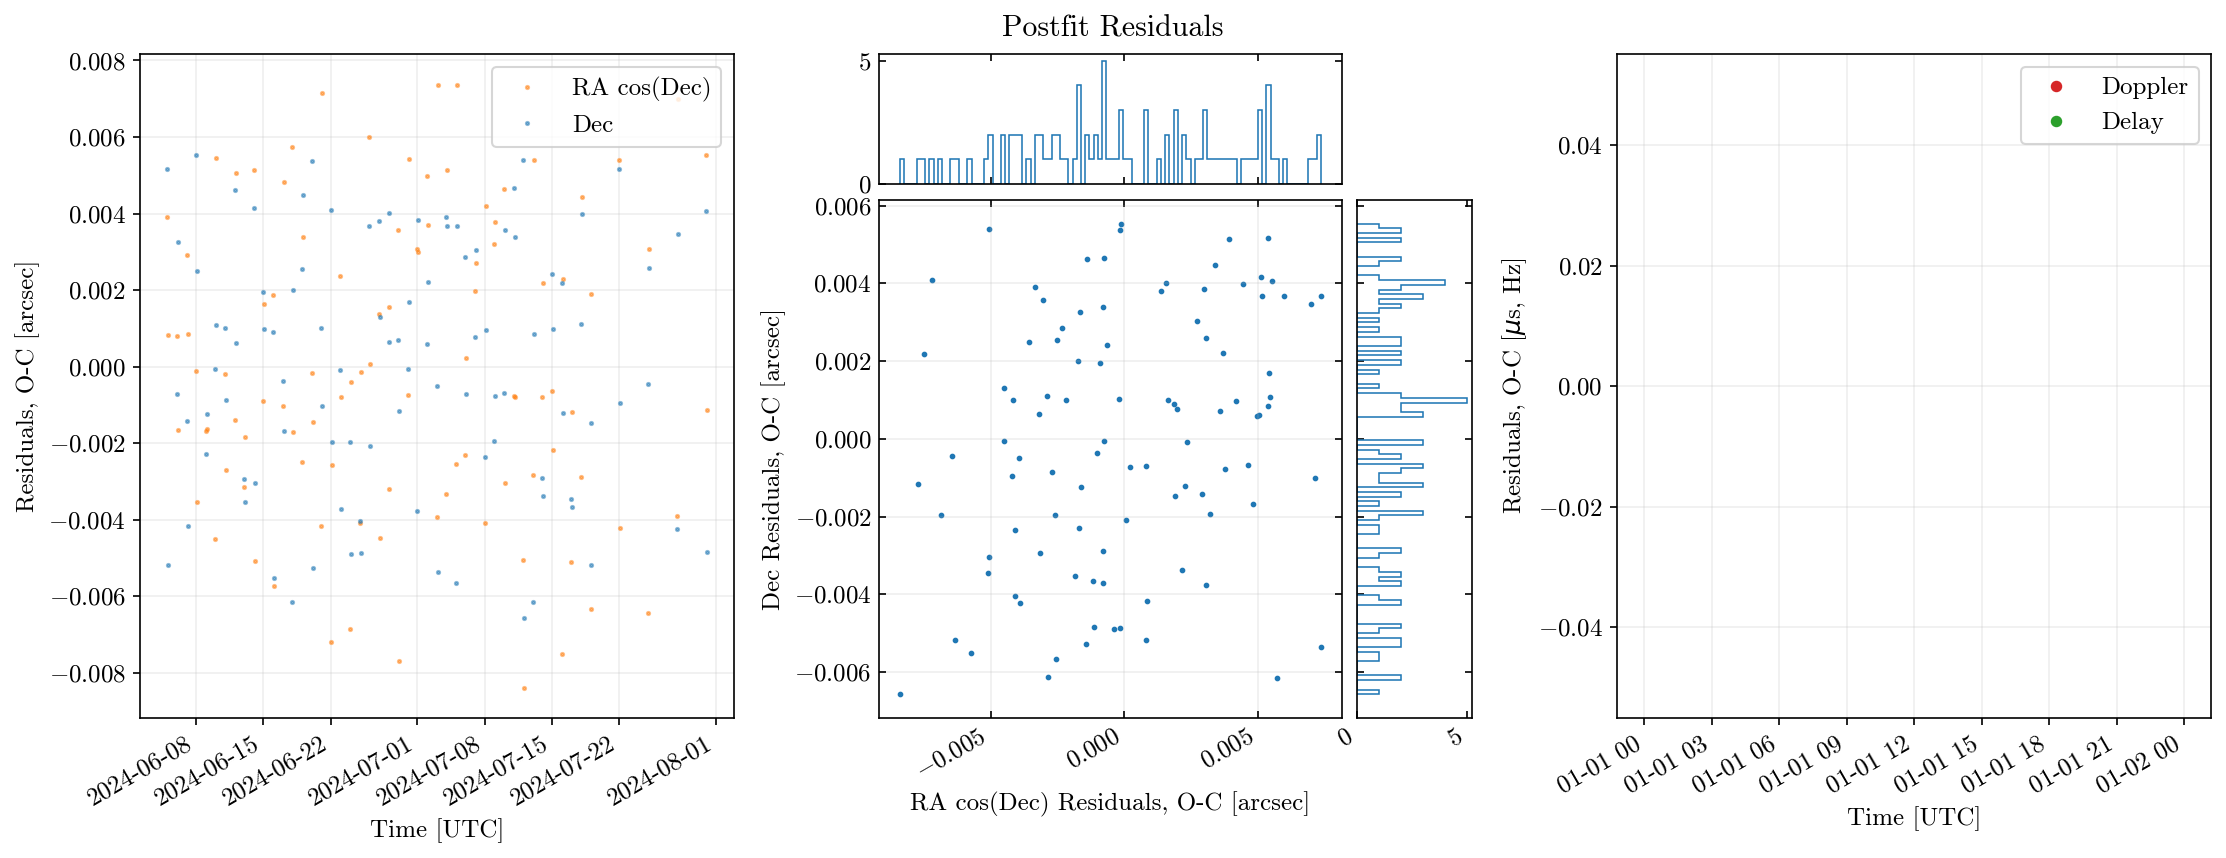

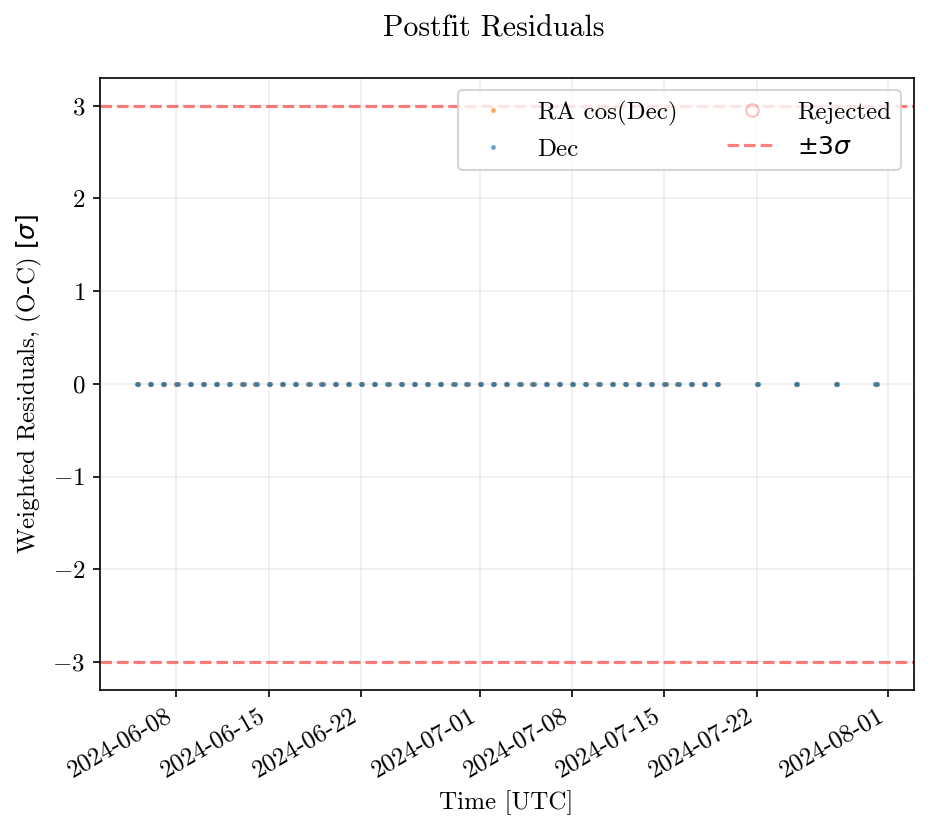

mean = [3.9065642431e-01 1.0053719390e+00 6.0440597041e+04 3.7424399315e+00 6.2824865468e+00 1.8655888592e-01]
cov = [[ 1.5981921057e-07  1.4678979839e-08  5.0334221680e-06 -8.1399092994e-08  1.1172110664e-07  3.7238271509e-08]
 [ 1.4678979839e-08  1.3824279054e-09  4.7067505978e-07 -7.5646013791e-09  1.0528071956e-08  3.3981461794e-09]
 [ 5.0334221680e-06  4.7067505978e-07  1.6070082791e-04 -2.5857501192e-06  3.5870011665e-06  1.1666885736e-06]
 [-8.1399092994e-08 -7.5646013791e-09 -2.5857501192e-06  4.1892650791e-08 -5.7799869723e-08 -1.8879552484e-08]
 [ 1.1172110664e-07  1.0528071956e-08  3.5870011665e-06 -5.7799869723e-08  8.0445638930e-08  2.5815306342e-08]
 [ 3.7238271509e-08  3.3981461794e-09  1.1666885736e-06 -1.8879552484e-08  2.5815306342e-08  8.6997633711e-09]]


In [4]:
from grss import fit
# import other numpy and time converter via astropy
import numpy as np
np.set_printoptions(precision=10, linewidth=np.inf)

from astropy.time import Time
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'STIXGeneral'
# matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'

font = {'family' : 'serif',
         'size'   : 11,
         'serif':  'cmr10'
         }

matplotlib.rc('font', **font)
matplotlib.rcParams["axes.formatter.use_mathtext"] = True

init_sol = {'t': obstime_to_mjd(o2['obsTime']), # MJD TDB
        'e': elems['e'], #0.3906575,
        'q': elems['q'], #1.00537975, # AU
        'tp': T0, #60446.77528505558, # MJD TDB
        'om': elems['Omega']*np.pi/180, # [rad]
        'w': elems['omega']*np.pi/180, # [rad]
        'i': elems['i']*np.pi/180} # [rad]


init_cov = 0.1*np.identity(6)


nongrav_info = {
    'a1': 0.0,
    'a2': 0.0,
    'a3': 0.0,
    'alpha': 1.0,
    'k': 0.0,
    'm': 2.0,
    'n': 0.0,
    'r0_au': 1.0,
    'radius': 0.0,
}
# specify JPL DExxx kernel used for planetary ephemerides
de_kernel = 440

add_a1 = False
add_a2 = False
add_a3 = False
ng_guess = 1e-13
if add_a1:
    # add a1 to init_sol
    init_sol['a1'] = ng_guess
    # add row and column for a1 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)
if add_a2:
    # add a2 to init_sol
    init_sol['a2'] = ng_guess
    # add row and column for a2 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)
if add_a3:
    # add a3 to init_sol
    init_sol['a3'] = ng_guess
    # add row and column for a3 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)

# add observations by the ESA's Gaia satellite (requires special treatment)
add_gaia_obs = False

# restrict timespan observations are considered for
t_min_tdb = None
t_max_tdb = None
# use lower resolution asteroid catalog debiasing scheme (JPL default, see Eggl+ 2020)
debias_lowres = False
# deweight outlier observations rather than eliminate them
deweight = True
eliminate = False
# limit the number of observations per night used in the fit. Avoids biases toward single nights that have many observations
num_obs_per_night = 4
# verbose filtering feedback
verbose = True

# add additional file containing observations in ADES format
optical_obs_file = "2024pdc25.xml"
body_id="SYNTH"

# # get optical observations from file
obs_df = fit.get_optical_obs(body_id, optical_obs_file, t_min_tdb, t_max_tdb, debias_lowres, deweight, eliminate, num_obs_per_night, verbose)

obs_df

n_iter_max = 20
fit_sim = fit.FitSimulation(init_sol, obs_df, init_cov, n_iter_max=n_iter_max, de_kernel=de_kernel, nongrav_info=nongrav_info)
fit_sim.reject_outliers = True
fit_sim.analytic_partials = True
fit_sim.reject_criteria = [2.0, 1.8]

fit_sim.filter_lsq()

# plot error bars for initial and final solution
n_sig = 1
labels = ['initial', 'final']
keys = list(fit_sim.x_init.keys())
init = list(fit_sim.x_init.values())
init_sig = np.diag(fit_sim.covariance_init)**0.5
nom = list(fit_sim.x_nom.values())
nom_sig = np.diag(fit_sim.covariance)**0.5
plt.figure(figsize=(10, 4), dpi=100)
for elem_idx in range(len(keys)):
    plt.subplot(1, len(keys), elem_idx+1)
    plt.errorbar(0, init[elem_idx], yerr=init_sig[elem_idx]*n_sig, fmt='o', capsize=10, lw=3, label=labels[0])
    plt.errorbar(0, nom[elem_idx], yerr=nom_sig[elem_idx]*n_sig, fmt='o', capsize=10, lw=3, label=labels[1])
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    plt.title(keys[elem_idx])
plt.legend(ncol=1, bbox_to_anchor=(1.9,0.6))
plt.tight_layout()
plt.suptitle(f'{n_sig}-sigma error bars for {body_id} initial and final solutions', y=1.05)
plt.show()

fit_sim.print_summary()

fit_sim.plot_summary(auto_close=True)

fit_sim.iters[1].plot_iteration_summary(title='Prefit Residuals', auto_close=True)
fit_sim.iters[-1].plot_iteration_summary(title='Postfit Residuals', auto_close=True)


mean_0 = np.array(list(init_sol.values())[1:])
cov_0 = init_cov
mean_f = np.array(list(fit_sim.x_nom.values()))
cov_f = fit_sim.covariance

if np.all(init_cov != 0):
    maha_dist_f, maha_dist_0, bhattacharya, bhatt_coeff = fit.get_similarity_stats(mean_0, cov_0, mean_f, cov_f)
    print(f'Mahalonobis distance between JPL and GRSS solution: {maha_dist_f:0.2f}')
    print(f'Mahalonobis distance between GRSS and JPL solution: {maha_dist_0:0.2f}')
    print(f'Bhattacharya distance between JPL and GRSS solution: {bhattacharya:0.4f}')
    print(f'Bhattacharya coefficient between JPL and GRSS solution: {bhatt_coeff:0.4f}')

print("mean = " + str(mean_f))
print("cov = " + str(cov_f))

In [5]:
def generate_sigma_points(x, P, alpha=0.1, beta=2, kappa=0):
    n = len(x)
    lam = alpha**2 * (n + kappa) - n

    S = np.linalg.cholesky((n + lam) * P)

    sigma = np.zeros((2*n + 1, n))
    sigma[0] = x

    for i in range(n):
        sigma[i+1]     = x + S[:, i]
        sigma[i+1+n]   = x - S[:, i]

    wm = np.full(2*n+1, 1/(2*(n+lam)))
    wc = wm.copy()

    wm[0] = lam/(n+lam)
    wc[0] = wm[0] + (1 - alpha**2 + beta)

    return sigma, wm, wc

def propagate_sigma_points(sigmas_elem, dt):
    propagated = []

    for sp in sigmas_elem:
        e, q, tp, Omega, omega, i = sp

        if e >= 1 or q <= 0:
            propagated.append(np.zeros(6))
            continue

        a = q / (1 - e)

        # approximate mean anomaly
        n = np.sqrt(MU / a**3)
        M = n * (dt - tp)

        nu = M_to_nu(M, e)

        r0, v0 = elements_to_cartesian(
            a, e, i, Omega, omega, nu
        )

        r_f, v_f = kepler_prop(r0, v0, dt)

        propagated.append(np.concatenate([r_f, v_f]))

    return np.array(propagated)



def reconstruct(sigmas, wm, wc):
    x_mean = np.sum(wm[:, None] * sigmas, axis=0)

    P = np.zeros((len(x_mean), len(x_mean)))

    for i in range(len(sigmas)):
        dx = sigmas[i] - x_mean
        P += wc[i] * np.outer(dx, dx)

    return x_mean, P


def elements_to_cartesian(a, e, i, Omega, omega, nu, mu=MU):
    """
    All angles in radians
    Returns r [AU], v [AU/day]
    """

    p = a * (1 - e**2)

    # PQW frame
    r_pqw = p / (1 + e*np.cos(nu)) * np.array([
        np.cos(nu), np.sin(nu), 0
    ])

    v_pqw = np.sqrt(mu/p) * np.array([
        -np.sin(nu), e + np.cos(nu), 0
    ])

    # Rotation matrices
    R3_O = np.array([
        [np.cos(Omega), -np.sin(Omega), 0],
        [np.sin(Omega),  np.cos(Omega), 0],
        [0, 0, 1]
    ])

    R1_i = np.array([
        [1, 0, 0],
        [0, np.cos(i), -np.sin(i)],
        [0, np.sin(i),  np.cos(i)]
    ])

    R3_w = np.array([
        [np.cos(omega), -np.sin(omega), 0],
        [np.sin(omega),  np.cos(omega), 0],
        [0, 0, 1]
    ])

    Q = R3_O @ R1_i @ R3_w

    r = Q @ r_pqw
    v = Q @ v_pqw

    return r, v

def M_to_nu(M, e, tol=1e-10):
    E = M
    for _ in range(100):
        dE = (M - (E - e*np.sin(E))) / (1 - e*np.cos(E))
        E += dE
        if abs(dE) < tol:
            break

    return 2*np.arctan2(
        np.sqrt(1+e)*np.sin(E/2),
        np.sqrt(1-e)*np.cos(E/2)
    )


# Extract elements properly
elem_dict = fit_sim.x_nom

e     = elem_dict['e']
q     = elem_dict['q']
tp    = elem_dict['tp']
Omega = np.deg2rad(elem_dict['om'])
omega = np.deg2rad(elem_dict['w'])
i     = np.deg2rad(elem_dict['i'])

mean_f = np.array([e, q, tp, Omega, omega, i])

# initial elements (IMPORTANT: radians)
mean_f = np.array([
    e,
    q,
    tp,
    Omega,
    omega,
    i
])

P0 = cov_f

t_impact = Time('2041-04-24T00:00:00', format='isot', scale='tdb') 
t_impact_mjd = t_impact.mjd

dt = t_impact_mjd - fit_sim.t_sol

# UT
sigmas, wm, wc = generate_sigma_points(mean_f, P0)

# propagate
sigmas_f = propagate_sigma_points(sigmas, dt)

# reconstruct
xf, Pf = reconstruct(sigmas_f, wm, wc)

r_f = xf[:3]
v_f = xf[3:]

print("Final state:")
print("r =", r_f)
print("v =", v_f)

print("\nCovariance:")
print(Pf)


Final state:
r = [-0.5293490741 -1.5147720834 -0.0048089549]
v = [1.2180378728e-02 1.7407399770e-03 3.4938144221e-06]

Covariance:
[[ 4.0700581263e-01  3.5054248779e-02 -6.6573415134e-05  9.7875471943e-04  3.0526520425e-03  9.7529126491e-06]
 [ 3.5054248779e-02  2.9594882524e-02  8.2884838399e-05 -7.0933127424e-05  4.1225456647e-04  1.4571977816e-06]
 [-6.6573415134e-05  8.2884838399e-05  3.0646853717e-07 -6.7772179009e-07 -1.3393465388e-09  4.6285684776e-10]
 [ 9.7875471943e-04 -7.0933127424e-05 -6.7772179009e-07  3.2603882487e-06  6.4686275935e-06  1.9848354409e-08]
 [ 3.0526520425e-03  4.1225456647e-04 -1.3393465388e-09  6.4686275935e-06  2.3734887451e-05  7.6617744015e-08]
 [ 9.7529126491e-06  1.4571977816e-06  4.6285684776e-10  1.9848354409e-08  7.6617744015e-08  2.4803932568e-10]]


mean_f: [3.9065642431e-01 1.0053719390e+00 6.0440597041e+04 3.7424399315e+00 6.2824865468e+00 1.8655888592e-01]
keys  : ['e', 'q', 'tp', 'om', 'w', 'i']
  e=0.390656, q=1.005372 AU
  tp=60440.5970 MJD
  om=214.4260 deg
  w =359.9600 deg
  i =10.6890 deg

Impact MJD: 66633.0000

UT mean position [AU]: [-0.8288529305 -0.5115470728 -0.2234684348]
Earth position   [AU]: [-0.8373988586 -0.5108976986 -0.2214307339]
Distance: 1317878 km

  B-PLANE RESULTS
  xi_mean    = +832458.13 km  (+130.6637 R_earth)
  zeta_mean  = -1315206.22 km  (-206.4364 R_earth)
  U_inf      = 8.1138 km/s
  b_coll     = 10850.68 km  (1.7031 R_earth)
  sigma_xi   = 1301358.06 km
  sigma_zeta = 13309881.76 km
  P_impact   = 2.600000e-06


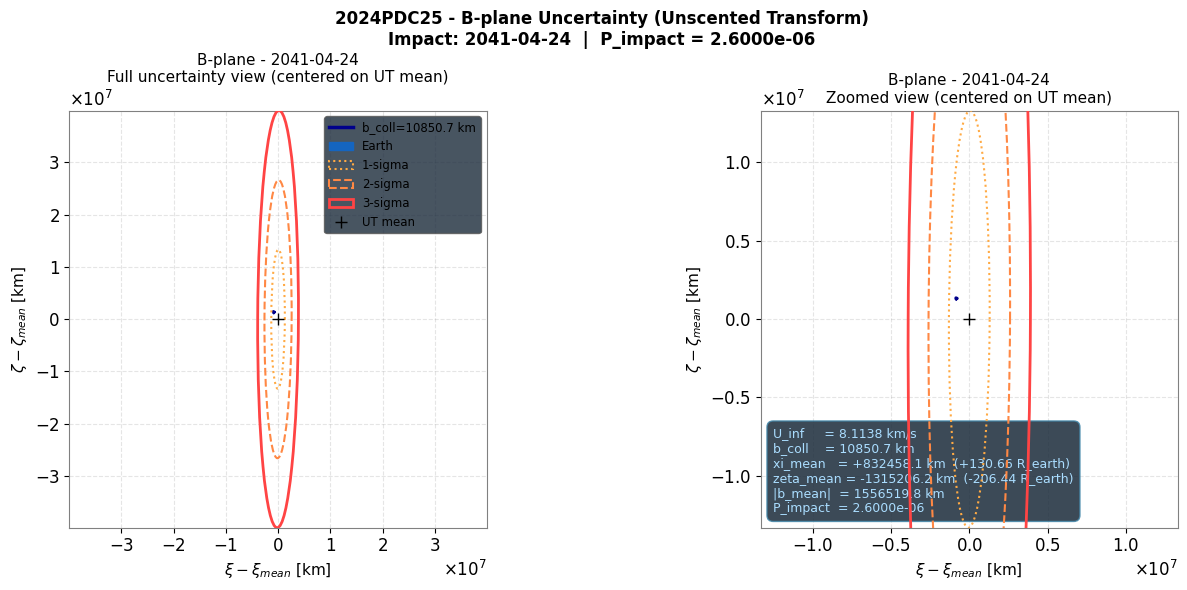

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from matplotlib.patches import Ellipse

# =============================================================================
# CONSTANTS
# =============================================================================
AU_KM   = 149597870.7
DAY_S   = 86400.0
MU      = 1.32712440018e20 * DAY_S**2 / (AU_KM*1e3)**3  # AU^3/day^2
R_earth_km  = 6371.0
mu_earth_km = 398600.4418

# =============================================================================
# INITIAL STATE — from fit_sim (GRSS cometary, ecliptic J2000)
# keys: e, q, tp, om, w, i
# om, w, i are already in RADIANS from GRSS
# =============================================================================
keys   = ['e', 'q', 'tp', 'om', 'w', 'i']
mean_f = np.array([fit_sim.x_nom[k] for k in keys])
# DO NOT convert angles — GRSS gives them in radians already
P0     = fit_sim.covariance   # 6x6

print("mean_f:", mean_f)
print("keys  :", keys)
print(f"  e={mean_f[0]:.6f}, q={mean_f[1]:.6f} AU")
print(f"  tp={mean_f[2]:.4f} MJD")
print(f"  om={np.degrees(mean_f[3]):.4f} deg")
print(f"  w ={np.degrees(mean_f[4]):.4f} deg")
print(f"  i ={np.degrees(mean_f[5]):.4f} deg")

# =============================================================================
# IMPACT DATE
# =============================================================================
t_impact     = Time('2041-04-24T00:00:00', format='isot', scale='tdb')
t_impact_mjd = t_impact.mjd
print(f"\nImpact MJD: {t_impact_mjd:.4f}")

# =============================================================================
# EARTH STATE AT IMPACT (heliocentric equatorial J2000)
# =============================================================================
t_sky = ts.tt(jd=t_impact_mjd + 2400000.5)
r_E   = (eph['earth'] - eph['sun']).at(t_sky).position.au
v_E   = (eph['earth'] - eph['sun']).at(t_sky).velocity.au_per_d

# =============================================================================
# ECLIPTIC → EQUATORIAL ROTATION
# =============================================================================
def ecliptic_to_equatorial(r, v):
    eps = np.radians(23.43928)
    R = np.array([
        [1,           0,            0],
        [0,  np.cos(eps), -np.sin(eps)],
        [0,  np.sin(eps),  np.cos(eps)]
    ])
    return R @ r, R @ v

# =============================================================================
# ELEMENTS → CARTESIAN (ecliptic J2000 PQW frame)
# =============================================================================
def elements_to_cartesian_ecliptic(e, q, tp, Omega, omega, i, t_mjd):
    """
    Cometary elements (ecliptic J2000) -> r, v in ecliptic J2000.
    tp is time of periapse [MJD TDB].
    t_mjd is target epoch [MJD TDB].
    """
    if e >= 1.0 or q <= 0:
        return None, None

    a = q / (1.0 - e)
    n = np.sqrt(MU / a**3)       # mean motion [rad/day]
    M = n * (t_mjd - tp)         # mean anomaly [rad]
    M = M % (2*np.pi)

    # Kepler equation
    E = float(M)
    for _ in range(200):
        dE = (M - E + e*np.sin(E)) / (1.0 - e*np.cos(E))
        E += dE
        if abs(dE) < 1e-12:
            break

    nu = 2.0 * np.arctan2(
        np.sqrt(1+e) * np.sin(E/2),
        np.sqrt(1-e) * np.cos(E/2)
    )

    p = a * (1 - e**2)
    r_mag = p / (1 + e*np.cos(nu))

    r_pqw = r_mag * np.array([np.cos(nu), np.sin(nu), 0.0])
    v_pqw = np.sqrt(MU/p) * np.array([-np.sin(nu), e+np.cos(nu), 0.0])

    # PQW -> ecliptic J2000
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i),     np.sin(i)

    Q = np.array([
        [ cO*co - sO*so*ci,  -cO*so - sO*co*ci,  sO*si],
        [ sO*co + cO*so*ci,  -sO*so + cO*co*ci, -cO*si],
        [ so*si,               co*si,              ci  ]
    ])

    r_ecl = Q @ r_pqw
    v_ecl = Q @ v_pqw

    # Rotate to equatorial J2000
    r_eq, v_eq = ecliptic_to_equatorial(r_ecl, v_ecl)
    return r_eq, v_eq

# =============================================================================
# SIGMA POINTS
# =============================================================================
def generate_sigma_points(x, P, alpha=1e-3, beta=2.0, kappa=0.0):
    n   = len(x)
    lam = alpha**2 * (n + kappa) - n
    try:
        S = np.linalg.cholesky((n + lam) * P)
    except np.linalg.LinAlgError:
        S = np.linalg.cholesky((n + lam) * (P + 1e-12*np.eye(n)))

    sigma = np.zeros((2*n+1, n))
    sigma[0] = x
    for i in range(n):
        sigma[i+1]   = x + S[:, i]
        sigma[i+1+n] = x - S[:, i]

    wm    = np.full(2*n+1, 1.0/(2*(n+lam)))
    wc    = wm.copy()
    wm[0] = lam/(n+lam)
    wc[0] = wm[0] + (1 - alpha**2 + beta)
    return sigma, wm, wc

# =============================================================================
# PROPAGATE SIGMA POINTS
# =============================================================================
def propagate_sigma_points(sigmas, t_mjd):
    """Each sigma point: [e, q, tp, om, w, i] (angles in radians)."""
    out = []
    for sp in sigmas:
        e, q, tp, Omega, omega, i = sp
        r, v = elements_to_cartesian_ecliptic(e, q, tp, Omega, omega, i, t_mjd)
        if r is None:
            out.append(np.zeros(6))
        else:
            out.append(np.concatenate([r, v]))
    return np.array(out)

# =============================================================================
# RECONSTRUCT
# =============================================================================
def reconstruct(sigmas, wm, wc):
    mean = np.einsum('i,ij->j', wm, sigmas)
    P    = np.zeros((sigmas.shape[1], sigmas.shape[1]))
    for i in range(len(sigmas)):
        d = sigmas[i] - mean
        P += wc[i] * np.outer(d, d)
    return mean, P

# =============================================================================
# B-PLANE
# =============================================================================
def bplane(r_ast, v_ast, r_E, v_E):
    d     = r_ast - r_E
    u     = v_ast - v_E
    U     = np.linalg.norm(u)
    S_hat = u / U

    cross = np.cross(v_E, S_hat)
    nc    = np.linalg.norm(cross)
    if nc < 1e-20:
        cross = np.cross(np.array([0.,0.,1.]), S_hat)
        nc    = np.linalg.norm(cross)
    xi_hat   =  cross / nc
    zeta_hat = -np.cross(S_hat, xi_hat)

    h     = np.cross(d, u)
    B_vec = np.cross(S_hat, h) / U

    xi   = np.dot(B_vec, xi_hat)
    zeta = np.dot(B_vec, zeta_hat)
    return xi, zeta, U

# =============================================================================
# PLOT ELLIPSE
# =============================================================================
def plot_cov_ellipse(mean, cov, n_std, ax, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, 0)
    order   = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle   = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
    width   = 2 * n_std * np.sqrt(eigvals[0])
    height  = 2 * n_std * np.sqrt(eigvals[1])
    ax.add_patch(Ellipse(xy=mean, width=width, height=height,
                         angle=angle, fill=False, **kwargs))

# =============================================================================
# RUN UT
# =============================================================================
sigmas, wm, wc = generate_sigma_points(mean_f, P0)
sigmas_f       = propagate_sigma_points(sigmas, t_impact_mjd)
xf, Pf         = reconstruct(sigmas_f, wm, wc)

print(f"\nUT mean position [AU]: {xf[:3]}")
print(f"Earth position   [AU]: {r_E}")
print(f"Distance: {np.linalg.norm(xf[:3]-r_E)*AU_KM:.0f} km")

# =============================================================================
# B-PLANE FOR EACH SIGMA POINT
# =============================================================================
xi_arr, zeta_arr, U_list = [], [], []
for s in sigmas_f:
    xi, zeta, U = bplane(s[:3], s[3:], r_E, v_E)
    xi_arr.append(xi * AU_KM)
    zeta_arr.append(zeta * AU_KM)
    U_list.append(U)

xi_arr   = np.array(xi_arr)
zeta_arr = np.array(zeta_arr)

# UT mean and covariance in b-plane
xi_mean   = float(np.einsum('i,i', wm, xi_arr))
zeta_mean = float(np.einsum('i,i', wm, zeta_arr))

P_b = np.zeros((2,2))
for i in range(len(xi_arr)):
    d    = np.array([xi_arr[i]-xi_mean, zeta_arr[i]-zeta_mean])
    P_b += wc[i] * np.outer(d, d)

# =============================================================================
# COLLISION RADIUS
# =============================================================================
U_kms   = float(np.mean(U_list)) * AU_KM / DAY_S
b_coll  = R_earth_km * np.sqrt(1.0 + 2*mu_earth_km / (R_earth_km * U_kms**2))

# =============================================================================
# IMPACT PROBABILITY
# =============================================================================
samples    = np.random.multivariate_normal([xi_mean, zeta_mean], P_b, 5000000)
radii      = np.linalg.norm(samples, axis=1)
P_impact   = np.mean(radii < b_coll)

print(f"\n{'='*50}")
print(f"  B-PLANE RESULTS")
print(f"{'='*50}")
print(f"  xi_mean    = {xi_mean:+.2f} km  ({xi_mean/R_earth_km:+.4f} R_earth)")
print(f"  zeta_mean  = {zeta_mean:+.2f} km  ({zeta_mean/R_earth_km:+.4f} R_earth)")
print(f"  U_inf      = {U_kms:.4f} km/s")
print(f"  b_coll     = {b_coll:.2f} km  ({b_coll/R_earth_km:.4f} R_earth)")
print(f"  sigma_xi   = {np.sqrt(P_b[0,0]):.2f} km")
print(f"  sigma_zeta = {np.sqrt(P_b[1,1]):.2f} km")
print(f"  P_impact   = {P_impact:.6e}")

# =============================================================================
# PLOT
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")
theta = np.linspace(0, 2*np.pi, 400)

# Compute ellipse semi-axes for smart zoom
eigvals, _ = np.linalg.eigh(P_b)
sig_max_km = np.sqrt(np.max(eigvals))

# Panel limits — both centered on UT mean
lims = [sig_max_km * 3,    # left: full uncertainty view
        sig_max_km * 1]     # right: zoomed

for ax_idx, lim_km in enumerate(lims):
    ax = axes[ax_idx]
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.2, color='gray', linestyle='--')

    # Earth at its actual position relative to UT mean
    earth_xi   = 0.0 - xi_mean      # Earth center in plot coords
    earth_zeta = 0.0 - zeta_mean

    # b_coll circle centered on Earth
    ax.plot(earth_xi + b_coll*np.cos(theta),
            earth_zeta + b_coll*np.sin(theta),
            '-', lw=2.5, color='darkblue', zorder=5,
            label=f'b_coll={b_coll:.1f} km')

    # Earth disk
    ax.add_patch(plt.Circle((earth_xi, earth_zeta), R_earth_km,
                 color='#1565c0', zorder=4, label='Earth'))

    # 1, 2, 3-sigma ellipses centered on UT mean (origin of this plot)
    plot_cov_ellipse([0, 0], P_b, 1, ax,
                     edgecolor='#ffaa44', lw=1.5,
                     linestyle=':', label='1-sigma', zorder=7)
    plot_cov_ellipse([0, 0], P_b, 2, ax,
                     edgecolor='#ff8844', lw=1.5,
                     linestyle='--', label='2-sigma', zorder=7)
    plot_cov_ellipse([0, 0], P_b, 3, ax,
                     edgecolor='#ff4444', lw=2.0,
                     linestyle='-', label='3-sigma', zorder=7)

    # UT mean at origin
    ax.plot(0, 0, '+', color='black', ms=8, mew=1,
            zorder=10, label='UT mean')

    ax.set_xlim(-lim_km, lim_km)
    ax.set_ylim(-lim_km, lim_km)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$\xi - \xi_{mean}$ [km]', color='black', fontsize=11)
    ax.set_ylabel(r'$\zeta - \zeta_{mean}$ [km]', color='black', fontsize=11)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_color('gray')

titles = ['Full uncertainty view (centered on UT mean)',
          'Zoomed view (centered on UT mean)']
for ax_idx, ax in enumerate(axes):
    ax.set_title(f'B-plane - {t_impact.iso[:10]}\n{titles[ax_idx]}',
                 color='black', fontsize=11)

axes[0].legend(fontsize=8.5, loc='upper right',
               facecolor='#1a2a3a', edgecolor='#555', labelcolor='black')

stats = (f"U_inf     = {U_kms:.4f} km/s\n"
         f"b_coll    = {b_coll:.1f} km\n"
         f"xi_mean   = {xi_mean:+.1f} km  ({xi_mean/R_earth_km:+.2f} R_earth)\n"
         f"zeta_mean = {zeta_mean:+.1f} km  ({zeta_mean/R_earth_km:+.2f} R_earth)\n"
         f"|b_mean|  = {np.sqrt(xi_mean**2+zeta_mean**2):.1f} km\n"
         f"P_impact  = {P_impact:.4e}")
axes[1].text(0.03, 0.03, stats, transform=axes[1].transAxes,
             fontsize=9, color='#aaddff', va='bottom',
             bbox=dict(boxstyle='round,pad=0.5',
                       facecolor='#1a2a3a', alpha=0.85,
                       edgecolor='#4488aa'))

plt.suptitle(f'2024PDC25 - B-plane Uncertainty (Unscented Transform)\n'
             f'Impact: {t_impact.iso[:10]}  |  P_impact = {P_impact:.4e}',
             color='black', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bplane_ut_2041.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()